# Lab 11: Árboles de desición

1. Importar iris dataset

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris #1. Importar iris dataset
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

In [17]:
iris = load_iris()

X = iris.data
y = iris.target

print("Shape de X:", X.shape)
print("Clases:", iris.target_names)
print("Características:", iris.feature_names)

Shape de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.

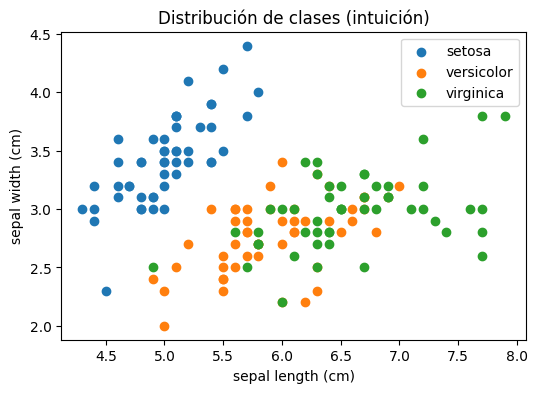

In [18]:
plt.figure(figsize=(6,4))

for i, target_name in enumerate(iris.target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=target_name)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Distribución de clases (intuición)")
plt.legend()
plt.show()

3. Dividir el dataset empleanto el metodo train_test_split de sklearn

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (105, 4)
Tamaño de X_test: (45, 4)


4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.

In [20]:
clf = DecisionTreeClassifier(
    criterion='gini',   # CART usa Gini
    max_depth=3,        # limitar profundidad (evita overfitting)
    random_state=42
)

clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Evaluación

In [21]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


5. Para el clasificador analice el gráfico de desición:

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  ```fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)```
  ```graph=tree.plot_tree(clf,class_names = iris.target_names,\```
                ```feature_names = iris.feature_names,\```
                ```impurity=False, filled=True,rounded=True )```

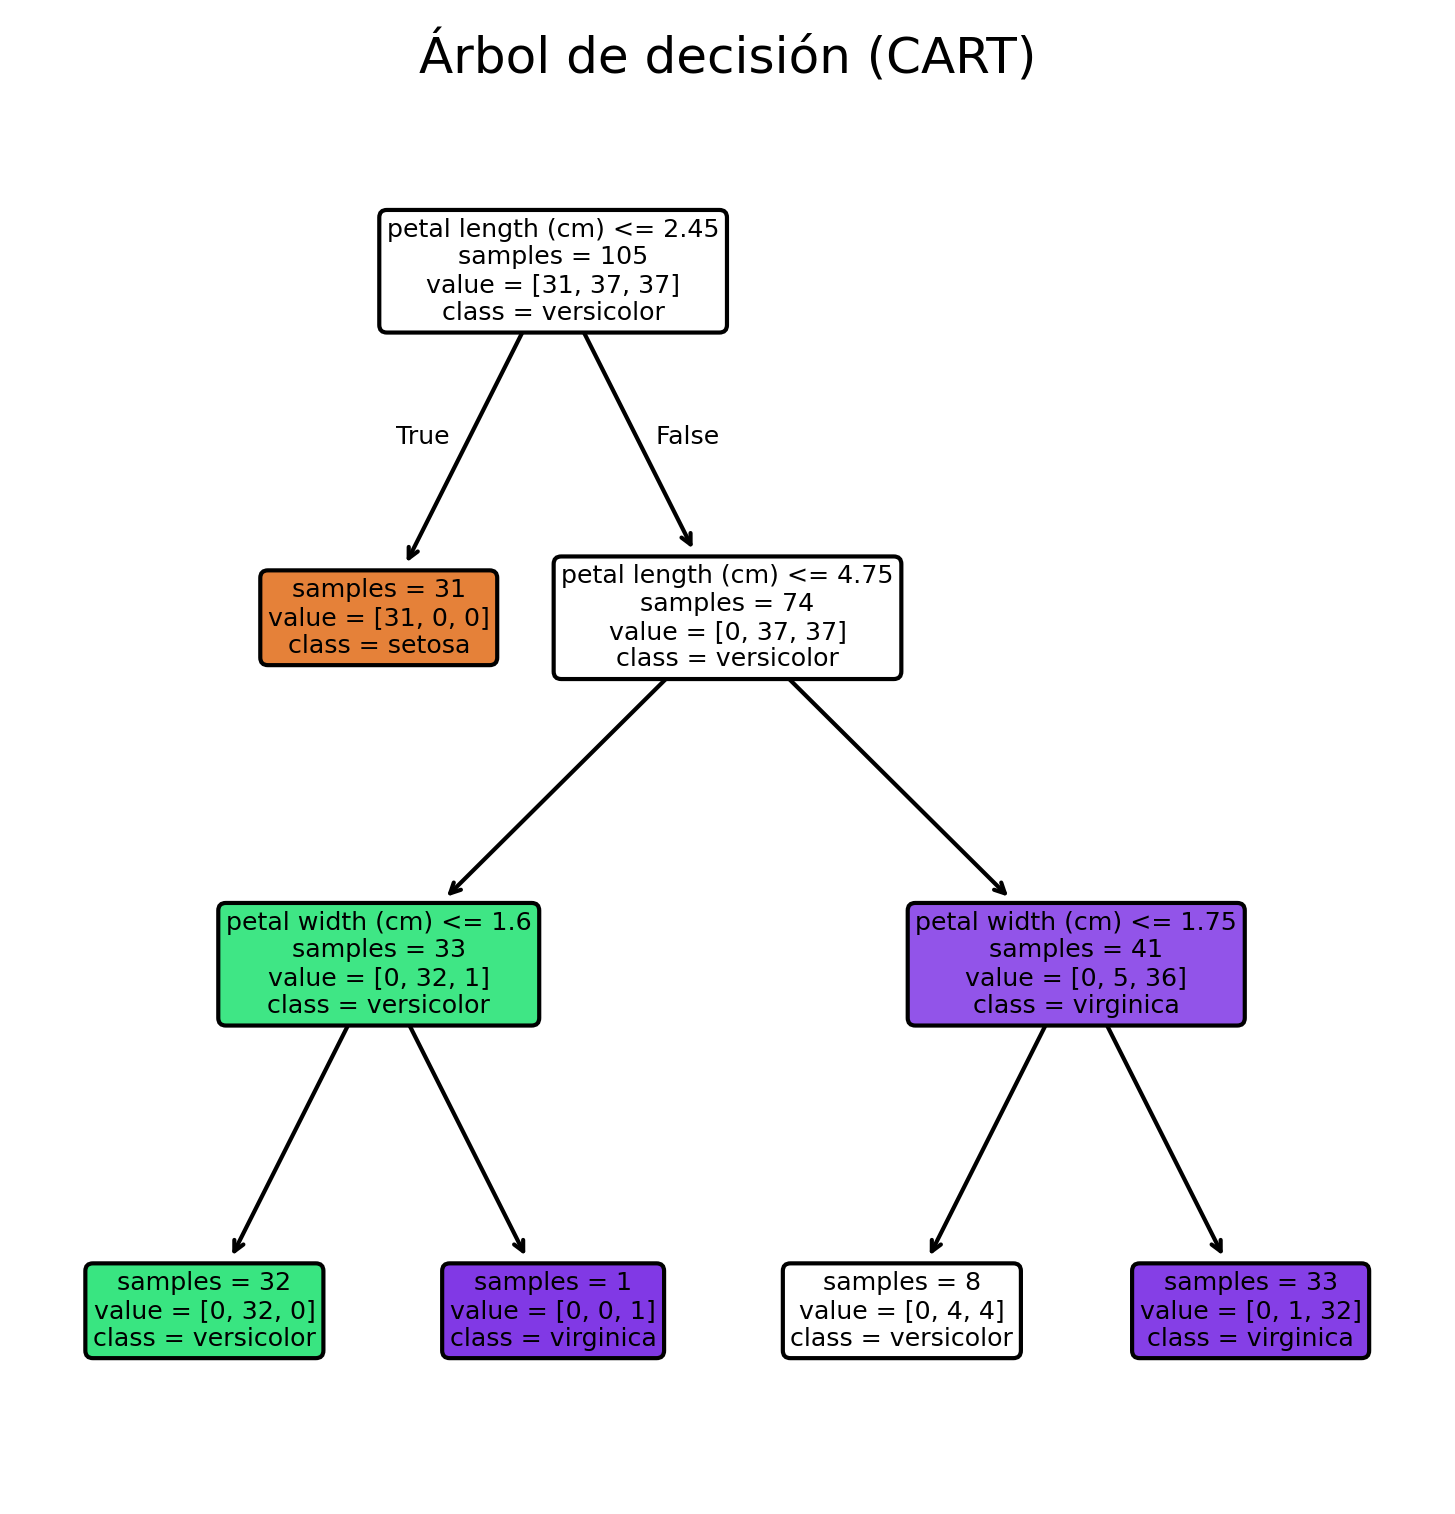

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=300)

tree.plot_tree(
    clf,
    class_names=iris.target_names,
    feature_names=iris.feature_names,
    impurity=False,
    filled=True,
    rounded=True
)

plt.title("Árbol de decisión (CART)")
plt.show()

6. Características importantes

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

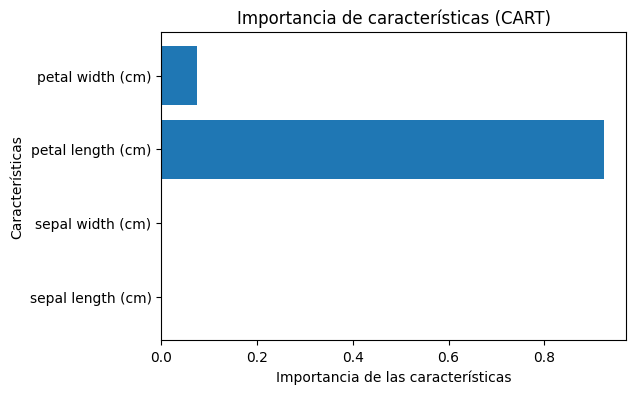

Importancias: [0.         0.         0.92510833 0.07489167]


In [23]:
importances = clf.feature_importances_
caract = iris.data.shape[1]

plt.figure(figsize=(6,4))
plt.barh(range(caract), importances)
plt.yticks(np.arange(caract), iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title("Importancia de características (CART)")
plt.show()

print("Importancias:", importances)

7. Fronteras de desición.

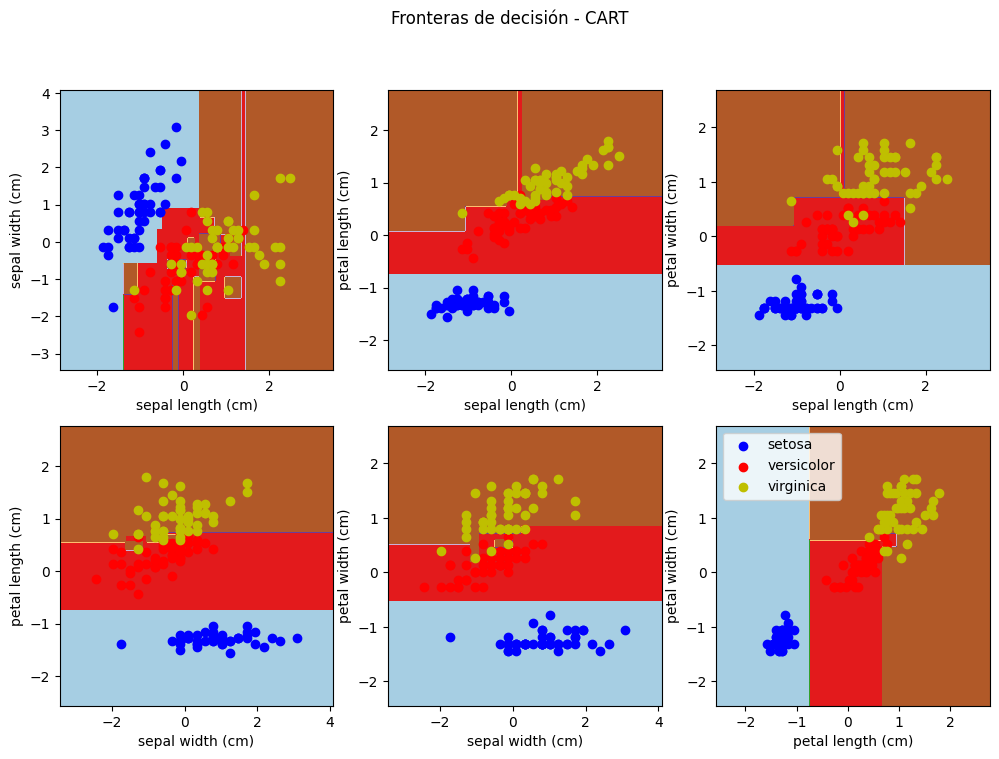

In [24]:
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

plt.figure(figsize=(12,8))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):

    X_pair = iris.data[:, pair]
    y_pair = iris.target

    # Mezclar datos
    idx = np.arange(X_pair.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)

    X_pair = X_pair[idx]
    y_pair = y_pair[idx]

    # Estandarizar
    mean = X_pair.mean(axis=0)
    std = X_pair.std(axis=0)
    X_pair = (X_pair - mean) / std

    # Entrenar modelo
    clf_pair = DecisionTreeClassifier().fit(X_pair, y_pair)

    # Crear malla
    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.subplot(2, 3, pairidx + 1)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])

    # Puntos reales
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y_pair == i)
        plt.scatter(X_pair[idx, 0], X_pair[idx, 1],
                    c=color, label=iris.target_names[i])

plt.suptitle("Fronteras de decisión - CART")
plt.legend()
plt.show()

In [25]:
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [26]:
print("Número de hojas:", clf.get_n_leaves())
print("Número total de nodos:", clf.tree_.node_count)

Número de hojas: 5
Número total de nodos: 9


In [27]:
clf = DecisionTreeClassifier(max_depth=3)

In [28]:
for d in [1, 2, 3, 5, 10]:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    print(f"Profundidad: {d}, Accuracy: {clf.score(X_test, y_test)}")

Profundidad: 1, Accuracy: 0.7111111111111111
Profundidad: 2, Accuracy: 0.9777777777777777
Profundidad: 3, Accuracy: 1.0
Profundidad: 5, Accuracy: 1.0
Profundidad: 10, Accuracy: 1.0


### **Análisis**

Las gráficas y resultados obtenidos muestran que el algoritmo CART logra clasificar de manera muy eficiente las especies del dataset Iris, alcanzando una alta precisión en el conjunto de prueba. La exploración inicial evidencia que la clase *setosa* se encuentra claramente separada de las demás, mientras que *versicolor* y *virginica* presentan cierto solapamiento. El árbol de decisión confirma que la característica más discriminante es la longitud del pétalo (*petal length*), ya que aparece en la raíz del árbol y concentra la mayor importancia dentro del modelo, seguida en menor medida por el ancho del pétalo (*petal width*); en contraste, las variables asociadas al sépalo tienen una contribución casi nula. Las fronteras de decisión muestran que CART divide el espacio de características mediante regiones rectangulares definidas por desigualdades del tipo (x_j < c), produciendo separaciones muy claras cuando se utilizan variables del pétalo y separaciones más difusas cuando se emplean únicamente variables del sépalo. En conjunto, los resultados evidencian que el modelo identifica correctamente las variables más relevantes y construye una clasificación interpretable y geométricamente consistente con la distribución natural de las especies.
